# Single station models with complete GEV, including $\xi$: is there a signal?

Requires R Kernel ($\geq$4.2.3)

## Aim of the experiment

The shape parameter $\xi$ of the generalized extreme value distribution is difficult to infer stably from the data. Therefore, we opt to set it to a fixed and spatially constant value. However, the choice of the value itself is non-trivial, as the shape parameter strongly influences the the whole distribution. E.g., if $\xi<0$, the distribution becomes a Weibull-Type distribution which has an upper bound on possible values. The Frechet-type distribution for $\xi>0$ has a lower bound, which does not produce any problems for the modelling of wind gusts. The Gumbel-type distribution for $\xi=0$ is unbounded. As we are hesitant to exclude potential extreme events, we would like to intentionally omit the Weibull-type distribution as a valid option, although it may theoretically occur. Thereby, we constrain the potential fixed values as $\xi\geq 0$. 

In this notebook, we fit non-stationary GEV-models to our wind gust data containing our predictors for location and scale and include the estimation of a shape parameter for each station. We calculate the model for 1000 bootstrap iterations in order to obtain 95%-credible intervals for the parameter estimation. If the credible intervals include 0, we conclude there is no signal for $\xi$ at the station and the Gumbel-assumption is justified. If the credible intervals are entirely positive, we say wind gusts at the station follow a Frechet-type distribution. Finally, if the entirety of the credibly interval is below 0, we say that wind gusts follow a Weibull-type distribution, which we would like to exclude. Therefore, if all stations are either Gumbel or Weibull, we regard the assumption from the manuscript that $\xi\equiv 0$ as justified.

## Functions for MLE and Bootstrapping

In [1]:
library(evd)

# 1. GEV likelihood function with non-stationary location and scale and a constant shape
fit_gev_ns <- function(obs, x_loc, x_scale, start_par = NULL) {
    x_loc <- as.matrix(x_loc)
    x_scale <- as.matrix(x_scale)
    
    n_loc <- ncol(x_loc)
    n_scale <- ncol(x_scale)
    
    if (is.null(start_par)) {
        start_par <- c(rep(0, n_loc), rep(0, n_scale), 0)  # last value = shape
        start_par[n_loc+1] <- log(var(obs))
        start_par[1] <- mean(obs)
    }
    
    negloglik <- function(par) {
        
        loc_par <- par[1:n_loc]
        scale_par <- par[(n_loc+1):(n_loc+n_scale)]
        shape <- par[n_loc+n_scale+1]
        
        loc <- as.vector(x_loc %*% loc_par)
        scale <- as.vector(exp(x_scale %*% scale_par))
        
        # catch too small scales
        #if(any(scale <= 1e-12)) return(1e10)
        if(any(scale <= 0)) return(1e10)
        
        # catch NAs & INFs 
        if(any(!is.finite(scale))) return(1e10)
        
        ll <- -sum(dgev(obs, loc=loc, scale=scale, shape=shape, log=TRUE))
        
        # L2-Penalty
        penalty <- 1e-12 * sum(par^2)
        
        return(ll + penalty)
    }
    
    fit <- optim(start_par, negloglik, method="BFGS", hessian=TRUE)
    
    par_names <- c(colnames(x_loc), colnames(x_scale), "shape")
    
    if (is.null(par_names[1])){
        par_names[1:n_loc] <- paste0("loc_", 1:n_loc) 
    } else {
        par_names[1:n_loc] <- paste0("loc_", par_names[1:n_loc]) 
    }
    
    if (is.null(par_names[(n_loc+1):(n_loc+n_scale)])){
        par_names[(n_loc+1):(n_loc+n_scale)] <- paste0("scale_", 1:n_scale)
    } else {
        par_names[(n_loc+1):(n_loc+n_scale)] <- paste0("scale_", par_names[(n_loc+1):(n_loc+n_scale)])
    }
    
    par_named <- setNames(fit$par, par_names)
    
    return(list(par=par_named, value=fit$value, convergence=fit$convergence, hessian=fit$hessian))
}

safe_fit_gev_ns <- function(obs, x_loc, x_scale, start_par = NULL, max_attempts = 3) {
    attempt <- 1
    repeat {
        fit <- try(fit_gev_ns(obs, x_loc, x_scale, start_par), silent = TRUE)
        if (!inherits(fit, "try-error")) return(fit)  # successful fit
            attempt <- attempt + 1
        if (attempt > max_attempts) {
            #warning("Fit failed after ", max_attempts, " attempts. Return NA.")
            return(list(par = rep(NA, ncol(x_loc)+ncol(x_scale)+1),
                        value = NA, convergence = 1, hessian = NA))
        }
    }
}

# --- 2. Block-Bootstrap of a fit ---
block_bootstrap <- function(obs, x_loc, x_scale, block_length = 2) {
    n <- length(obs)
    n_blocks <- ceiling(n / block_length)
    
    blocks <- split(seq_len(n), ceiling(seq_len(n)/block_length))
    sample_blocks <- sample(blocks, n_blocks, replace = TRUE)
    boot_idx <- unlist(sample_blocks)
    boot_idx <- boot_idx[boot_idx <= n]
    
    obs_boot <- obs[boot_idx]
    x_loc_boot <- x_loc[boot_idx,,drop=FALSE]
    x_scale_boot <- x_scale[boot_idx,,drop=FALSE]
    
    fit <- safe_fit_gev_ns(obs_boot, x_loc_boot, x_scale_boot)
    return(fit$par)
}

# --- 3. Bootstrap confidence intervals ---
bootstrap_ci <- function(obs, x_loc, x_scale, n_boot=100, block_length=2, conf_level=0.95) {
    
    n_loc <- ncol(x_loc)
    n_scale <- ncol(x_scale)
    n_par <- ncol(x_loc) + ncol(x_scale) + 1
    par_names <- c(colnames(x_loc), colnames(x_scale), "shape")
    
    if (is.null(par_names[1])){
        par_names[1:n_loc] <- paste0("loc_", 1:n_loc) 
    } else {
        par_names[1:n_loc] <- paste0("loc_", par_names[1:n_loc]) 
    }
    
    if (is.null(par_names[(n_loc+1):(n_loc+n_scale)])){
        par_names[(n_loc+1):(n_loc+n_scale)] <- paste0("scale_", 1:n_scale)
    } else {
        par_names[(n_loc+1):(n_loc+n_scale)] <- paste0("scale_", par_names[(n_loc+1):(n_loc+n_scale)])
    }
    
    boot_mat <- matrix(NA, nrow=n_boot, ncol=n_par)
    colnames(boot_mat) <- par_names
    
    for (i in 1:n_boot) {
        boot_mat[i,] <- block_bootstrap(obs, x_loc, x_scale, block_length)
    }

    no.na.n <- sum(!is.na(boot_mat[,1])) # number of successful fits
    
    alpha <- (1 - conf_level)/2
    ci_lower <- apply(boot_mat, 2, quantile, probs=alpha, na.rm=TRUE)
    ci_upper <- apply(boot_mat, 2, quantile, probs=1-alpha, na.rm=TRUE)
    ci_mean <- apply(boot_mat, 2, mean, na.rm=TRUE)
    
    ci <- data.frame(lower=ci_lower, mean=ci_mean, upper=ci_upper, row.names=par_names)
    
    return(list(ci=ci, no.na.n=no.na.n))
}

## load data

In [2]:
########################
# Setup and preparation
########################

# read observations
fx_train <- read.table("data/fx_for_training.csv", header =TRUE, sep=",")
dates <- fx_train$date
fx_train <- fx_train[,2:dim(fx_train)[2]]
rownames(fx_train) <- dates
stat_ids <- c(unlist(unname(read.table("data/used_station_ids.csv", skip=1, colClasses = c("character")))))

# get altitude difference
stat_info <- read.table(paste("data/used_stations_109.csv", sep=""), sep=",", header=TRUE)
z_station <- stat_info$Stationshoehe
z_grid <- unname(unlist(read.table(paste("data/rea6_elevation.txt",sep=""))))
z_train <- z_station-z_grid

# Read wind gust data fomr COSMO-REA6
vmax_train <- read.table("data/vmax_for_training.csv", header =TRUE, sep=",")
vmax_train <- vmax_train[,2:dim(vmax_train)[2]]
rownames(vmax_train) <- dates
vmean_train <- read.table("data/vmean_for_training.csv", header =TRUE, sep=",")
vmean_train <- vmean_train[,2:dim(vmean_train)[2]]
rownames(vmean_train) <- dates

## fit model and estimate CIs

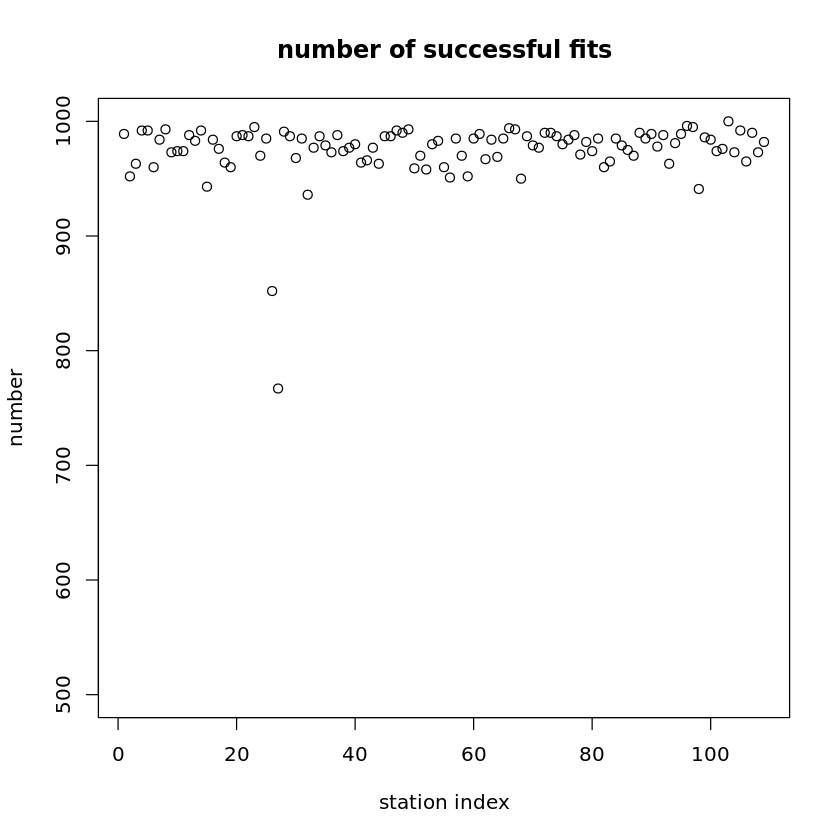

In [4]:
# loop over stations
#dir.create("Model_fits/LocMod_xi")
CIs = list()
fit.success = list()
for (istat in 1:length(stat_ids)){
    # select station data
    fx_stat <- fx_train[,istat]
    vmax_stat <- vmax_train[,istat]
    vmean_stat <- vmean_train[,istat]

    # construct observation vector
    y_stat <- fx_stat - vmean_stat

    # construct predictor matrices for location and scale
    x_loc <- cbind(Intercept=1, 
                   vmax=(vmax_stat-mean(vmax_stat))/sd(vmax_stat),
                   vmean=(vmean_stat-mean(vmean_stat))/sd(vmean_stat))#,delta_z=z_train[istat]) delta_z is part of the intercept locally
    x_scale <- cbind(Intercept=1, 
               vmax=(vmax_stat-mean(vmax_stat))/sd(vmax_stat),
               vmean=(vmean_stat-mean(vmean_stat))/sd(vmean_stat))
    
    boot <- bootstrap_ci(y_stat, x_loc, x_scale, n_boot=1000, block_length=3)
    CIs[[istat]] <- boot$ci
    fit.success[[istat]] <- boot$no.na.n
}

### --- execution might take some time ---

plot(1:109,unlist(fit.success), main="number of successful fits", xlab="station index", ylab= "number", ylim=c(500,1000))

In [5]:
#############
# Store data
#############

save(CIs, file="Model_fits/LocMod_xi/param_confindence_intervals.RData")

#load(file="Model_fits/LocMod_xi/param_confindence_intervals.RData")

###############################
# save shape parameters as csv
###############################

lower = list()
mean_l = list()
upper = list()

for (i in 1:length(CIs)){
    
    lower[[i]] <- CIs[[i]]$lower[7]
    mean_l[[i]] <- CIs[[i]]$mean[7]
    upper[[i]] <- CIs[[i]]$upper[7]
}
xis <- list(stat_id=c(stat_ids),lower=unlist(lower),mean=unlist(mean_l),upper=unlist(upper),nboot=unlist(fit.success))
xis <- data.frame(xis)
write.table(xis, file="Model_fits/LocMod_xi/xi_confidence_intervals.csv", sep=",", row.names=F)

## analyze results

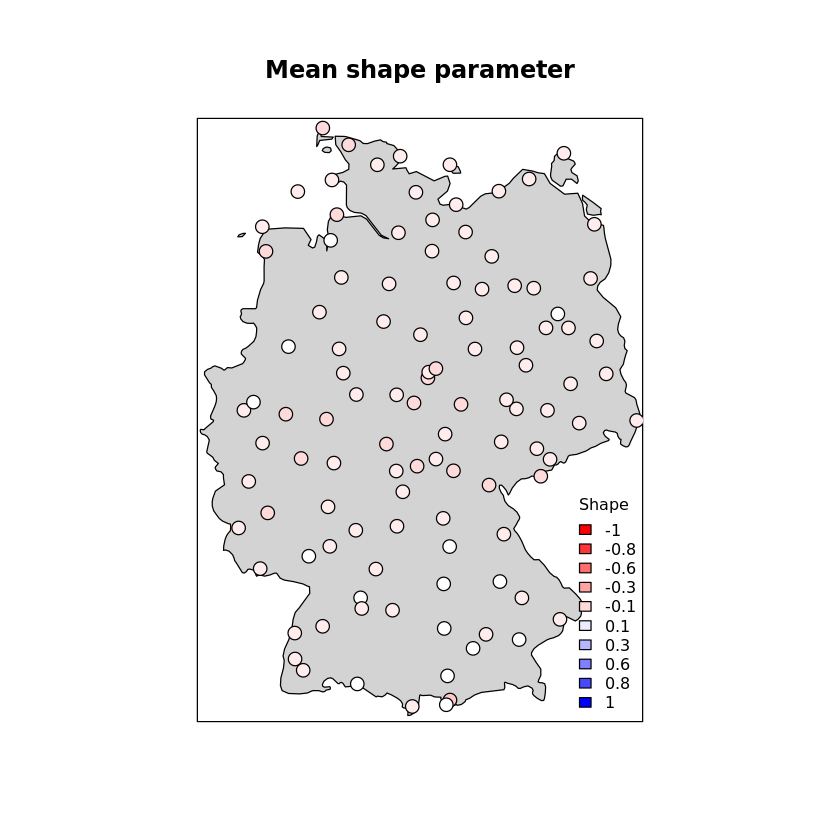

In [20]:
#if(!require(maps)) install.packages("maps")
library(maps)

# Data
lon <- stat_info$geoLaenge
lat <- stat_info$geoBreite

# plot 1 
values <- xis$mean
max_val <- 1#max(abs(values))

# make color scheme (e.g. red to blue)
neg_colors <- colorRampPalette(c("red","white"))(15)
pos_colors <- colorRampPalette(c("white","blue"))(15)
bipolar_colors <- c(neg_colors, pos_colors)
point_colors <- bipolar_colors[cut(values,
                   breaks = seq(-max_val, max_val, length.out = 30),
                   include.lowest = TRUE)]


par(mfrow=c(1,1))
# plot Germany map
map("world", "Germany", fill=TRUE, col="lightgray", bg="white")
box() 

# add smartie plot of xi parameters
points(lon, lat, pch=21, bg=point_colors, cex=1.5)

legend("bottomright",
       legend = round(seq(-max_val, max_val, length.out = 10), 1),
       fill   = bipolar_colors[seq(1, 30, length.out = 10)],
       title  = "Shape",
       bty    = "n", cex=0.8)
title("Mean shape parameter")

- $\xi\approx0$ for most stations, some outliers with Weibull-Type GEV. No recognizable spatial pattern.
- Note on the map plot: the smartie plot has more color bins than implied by the legend and can depict finer differences.

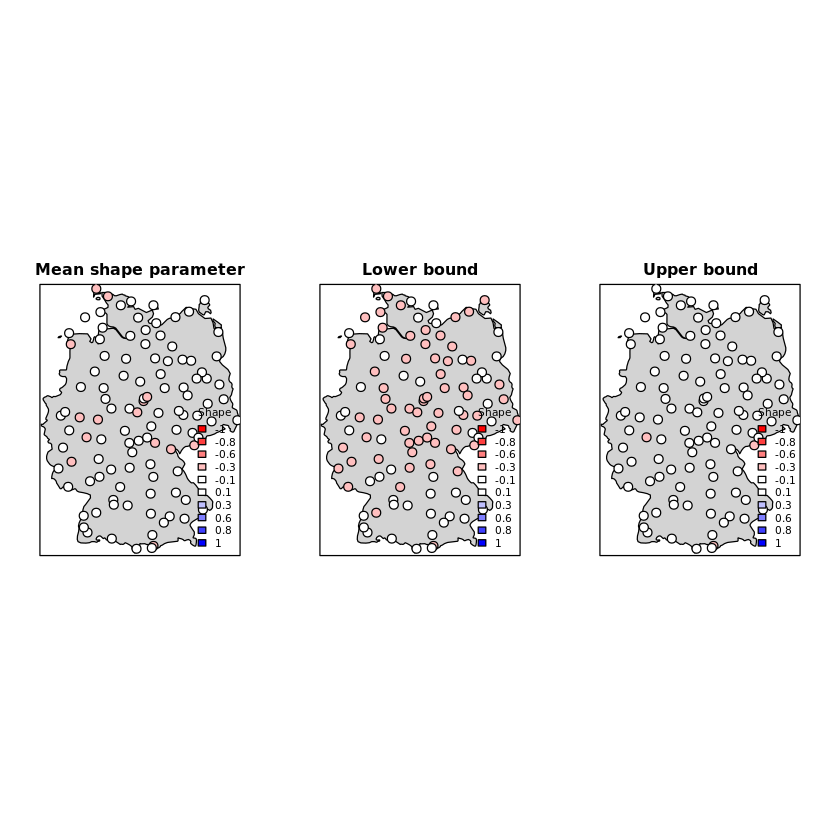

In [11]:
#################################################################
# visualize estimates on map to see if there is a spatial signal
#################################################################

wtp <- list(xis$mean, xis$lower, xis$upper)
titles <- c("Mean shape parameter", "Lower bound", "Upper bound")
#png("Model_fits/LocMod_xi/shape_parameter_map.png", width=1200,height=400)
par(mfrow=c(1,3), mar = c(4, 4, 2, 1), oma = c(0, 0, 0, 0))
for (i in 1:3){
    # plot 1 
    values <- wtp[[i]]
    max_val <- 1#max(abs(values))
    
    # make color scheme (e.g. red to blue)
    neg_colors <- colorRampPalette(c("red","white"))(5)
    pos_colors <- colorRampPalette(c("white","blue"))(5)
    bipolar_colors <- c(neg_colors, pos_colors)
    point_colors <- bipolar_colors[cut(values,
                       breaks = seq(-max_val, max_val, length.out = 10),
                       include.lowest = TRUE)]
    
    # plot Germany map
    map("world", "Germany", fill=TRUE, col="lightgray", bg="white")
    box() 
    
    # add smartie plot of xi parameters
    points(lon, lat, pch=21, bg=point_colors, cex=1.5)
    
    legend("bottomright",
           legend = round(seq(-max_val, max_val, length.out = 10), 1),
           fill   = bipolar_colors[seq(1, 10, length.out = 10)],
           title  = "Shape",
           bty    = "n", cex=0.8)
    title(titles[i])

}
#dev.off()

In [12]:
xis[which(xis$mean>0),]

,stat_id,lower,mean,upper,nboot
,<chr>,<dbl>,<dbl>,<dbl>,<int>
43,02290,0.0003910495,0.048229686,0.09480339,977
89,04928,-0.0425666320,0.007121131,0.05265561,985
96,05426,-0.0904500150,0.046123237,0.11701439,996
103,05792,-0.0106251465,0.033148553,0.07635529,1000


In [13]:
stat_info[which(xis$mean>0),c("Stations_id","Stationsname", "Stationshoehe")]

,Stations_id,Stationsname,Stationshoehe
,<int>,<chr>,<int>
43,2290,Hohenpeissenberg,977
89,4928,Stuttgart (Schnarrenberg),314
96,5426,Weinbiet,553
103,5792,Zugspitze,2956


On average $\xi\leq0$ almost everywhere. Exceptions:
- 02290 Hohenpeißenberg $\rightarrow$ mountain station
- 04928 Stuttgart (Schnarrenberg)
- 05426 Weinbiet $\rightarrow$ mountain station
- 05792 Zugspitze $\rightarrow$ mountain station

the lower bound for these four stations is $<0$, so there is no clear signal. However, some of these stations appear as the *usual suspects* for outliers.